For an optical depth of 0.25, solar zenith angle of 82 degrees, and atmospheric thickness of 100.000 km:
Fraction of photons reaching the surface: 0.778
Fraction of photons extinguished: 0.222
Mean path length: 2867.316
Transmittance: 0.166


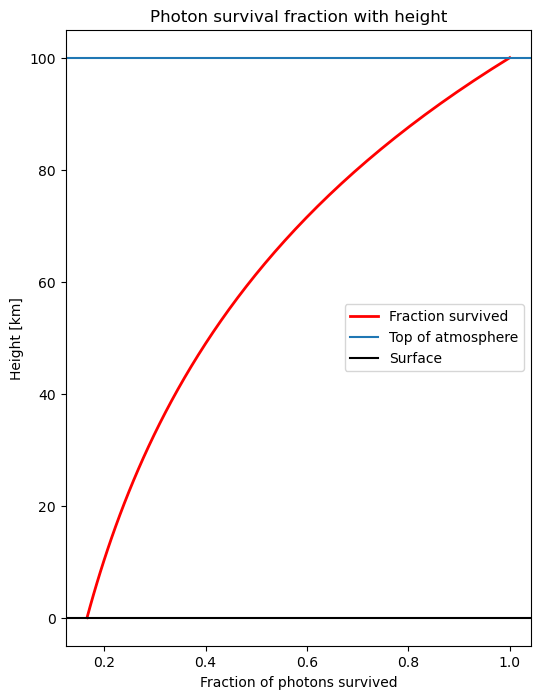

0.13917310096006547


In [9]:
import numpy as np
import matplotlib.pyplot as plt

#-----------------------
# constants
Zatm = 100 # arbitrary value (troposphere thickness) [km]
theta = 82
theta_rad = np.deg2rad(theta)
mu = np.cos(theta_rad) # set solar zenith angle theta
TOD = .25 # set total optical depth
N = 100000 # number of photons

#-----------------------
# individual photon optical depths
rand_array = np.random.rand(N) # sampled optical depth for N number of photons
tau = -np.log(1-rand_array)

#-----------------------
# outcome
yes = tau >= TOD
no = tau < TOD

# path length
L = (Zatm*tau)/(mu*TOD)
transmit = np.exp(-TOD / mu)

# statistics
yays = np.mean(yes)
nays = np.mean(no)

print(f"For an optical depth of {TOD:.2f}, solar zenith angle of {theta:.0f} degrees, and atmospheric thickness of {Zatm:.3f} km:")
print(f"Fraction of photons reaching the surface: {yays:.3f}")
print(f"Fraction of photons extinguished: {nays:.3f}")
print(f"Mean path length: {np.mean(L):.3f}")
print(f"Transmittance: {transmit:.3f}")

# histogram
# optical depth required
z_vals = np.linspace(0, Zatm, 50)
tau_req = (TOD/mu) * (1-z_vals/Zatm)
survived = np.exp(-tau_req)
plt.figure(figsize=(6, 8))
dz = z_vals[1] - z_vals[0]
plt.plot(survived, z_vals, 'r-', linewidth=2, label="Fraction survived")
plt.axhline(100,label="Top of atmosphere")
plt.axhline(0,color='k',label="Surface")
plt.xlabel("Fraction of photons survived")
plt.ylabel("Height [km]")
plt.title("Photon survival fraction with height")
plt.legend()
plt.show()

tau_efold = -mu * np.log(1/np.e)
print(tau_efold)

Part III: Experiments
1) tau = 1
2) transmittance = .135
3) The surface would be dark if the sun is at the very horizon since the solar zenith angle would reach 90 degrees, mu would therefore be 0, and the transmittance would come out to 0, meaning no photons are reaching the surface.
4) The higher the total optical depth, the less transmittance there is for increasing heights in the atmosphere.

Part IV: AERONET

For the La Jolla station, on February 23, 2020, the AOD at 500 nm goes from around .18 at 4 pm to .12 at midnight, depending on the solar zenith angle which decreases from 71 to 41.7 at 7:50 pm, then increases to 82 degrees (or ideally 0) at midnight. Sea salt is the major contributor to the aerosol composition at this station. with these AOD and theta values, I can use my model to find that the idealized transmittance changes from .575 at 4 pm to .422 at midnight. With a daily mean value tau of ~ .15, the surface transmittance ranges from .82 at its peak to .422 at its lowest throughout the day. For a max theta of 41.7 degrees, the transmittance changes from .853 to .788 as the AOD changes. Through this, we can observe that the solar zenith angle changes the transmittance at the surface the most compared to the change in tau or AOD. 

Note: measurements of solar zenith angle are directly applied and the observation limits at horizon levels are not considerated, as realistically the solar zenith angle at midnight should be >> than 90 degrees. 


Part V: Investigation

Based on the AERONET measurements for the same day, I'd like to observe the changes in UV light throughout the day to measure how the UV index can change with AOD or solar zenith angle. I propose that its trend should be similar to the trend observed with 500 nm light measured in the last part. 

With the AERONET data, the AOD goes from 2.5 to around 1.8 as the solar zenith angle changes from 4 pm to 12 am, where the solar zenith angle follows the same trend as before. The transmittance then goes from .445 to .718 from 4 pm to around 7:30 pm, where the solar zenith angle is the lowest, and then decreases to .166 (or ideally 0) at midnight. Here we can see a much greater transmittance of UV light compared to 500 nm visible light from these ranges, and that it, as expected, follows the same patterns with solar zenith angle. We also note that for this data, the highest UV index would be present around 7 pm, which may be unrealistic. Further investigation is necessary. 
